In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
mean1 = 55
std_dev1 = 10
num_samples = 500

column1_numbers = np.random.normal(mean1, std_dev1, num_samples)
column1_numbers = np.clip(column1_numbers, 30, 120)
column1_numbers = np.round(column1_numbers).astype(int)

mean2 = 18
std_dev2 = 3

column2_numbers = np.random.normal(mean2, std_dev2, num_samples)
column2_numbers = np.clip(column2_numbers, 12, 26)
column2_numbers = np.round(column2_numbers).astype(int)

column3_numbers = np.random.randint(2, size=num_samples)
column3_numbers[column1_numbers > mean1] =1

data = {"Miles_Per_week": column1_numbers,
        "Farthest_run": column2_numbers,
        "Qualified_Boston_Marathon": column3_numbers}

df = pd.DataFrame(data)
df

,Miles_Per_week,Farthest_run,Qualified_Boston_Marathon
0,63,19,1
1,65,21,1
2,41,23,0
3,50,17,0
4,56,22,1
...,...,...,...
495,63,20,1
496,70,19,1
497,58,14,1
498,67,15,1


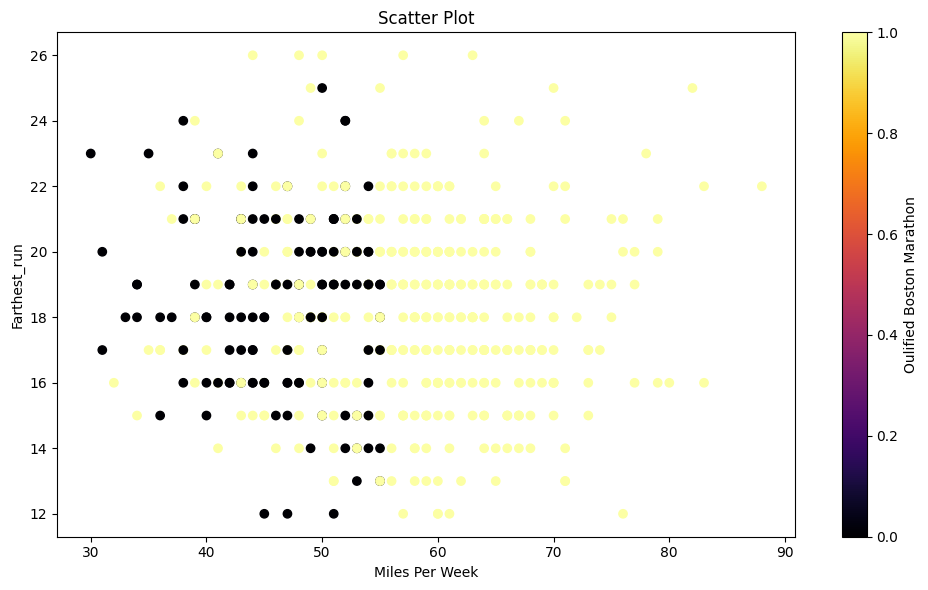

In [5]:
plt.figure(figsize=(10,6))
plt.scatter(df['Miles_Per_week'], df['Farthest_run'], c=df['Qualified_Boston_Marathon'],cmap='inferno')
plt.xlabel('Miles Per Week')
plt.ylabel('Farthest_run')
plt.title('Scatter Plot')
plt.colorbar(label='Oulified Boston Marathon')
plt.tight_layout()
plt.show()

In [7]:
X= df.iloc[:, 0:2]
y=df.iloc[:, 2]


In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test= train_test_split(X,y, random_state=32, test_size=0.2)

In [11]:
from sklearn.svm import SVC

In [12]:
model=SVC()

In [13]:
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [14]:
model.score(X_test,y_test)

0.77

SVC(C=0.1) içindeki C parametresi, SVM modelinde regularization strength yani hata toleransı ile karar sınırı sadeliği arasındaki dengeyi ayarlar.

Kısa Mantık

C değeri:

Büyükse → model eğitim verisini daha iyi ezberlemeye çalışır
Küçükse → model daha sade/genel bir sınır çizer

Büyük C (örn 100)

Model der ki:

"Tek bir hata bile istemiyorum."

Sonuç:

Veri noktalarına çok yapışır
Karmaşık boundary oluşur
Overfit riski artar

Model der ki:

"Biraz hata olabilir, önemli olan genel yapı."

Sonuç:

Daha smooth sınır
Daha iyi test başarısı olabilir

In [27]:
#regularization
model_reg0=SVC(C=.1)



In [28]:
model_reg0.fit(X_train, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [29]:

model_reg0.score(X_test,y_test)

0.78

Kısa Mantık

gamma şunu kontrol eder:

Bir eğitim noktası çevresini ne kadar etkilesin?

Yüksek gamma → sadece çok yakın çevreyi etkiler
Düşük gamma → daha geniş alanı etkiler
Sonuçları
Küçük gamma (0.01, 0.1)
Daha yumuşak / smooth boundary
Daha genel model
Underfitting olabilir
Büyük gamma (10, 100)
Çok kıvrımlı boundary
Veriye yapışır
Overfitting riski yüksek

In [ ]:
#gamma

model_gamma0=SVC(gamma=0.1)

In [31]:
model_gamma0.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [32]:
model_gamma0.score(X_test, y_test)

0.72

In [34]:
model_gamma1=SVC(gamma=1)
model_gamma1.fit(X_train,y_train)
model_gamma1.score(X_test,y_test)

0.73

kernel, SVM modelinin veriyi nasıl ayıracağını belirleyen yöntemdir. Yani:

Karar sınırını düz mü çizecek, eğri mi çizecek, daha karmaşık mı yapacak?

en popüler : kernel='rbf' Eğri / karmaşık sınır çizer.

Kernel	Karar Sınırı
linear	düz çizgi
rbf	   kıvrımlı
poly	polinom
sigmoid	sigmoid

In [35]:
#kernel
model_linear=SVC(kernel='linear')
model_linear.fit(X_train,y_train)
model_linear.score(X_test,y_test)

0.77

In [36]:
model_rbf=SVC(kernel='rbf')
model_rbf.fit(X_train,y_train)
model_rbf.score(X_test,y_test)

0.77